# 1 SIDNE Model 2035-2050 
(Spain Industry Decarbonisation with Nuclear Energy) 

This first module focuses in the Chemical Industry decarbonization with SMR-CHP 
(Economic analysis using PyPSA opensource toolbox)

Hypothesis: 
- Demand data from MECs (3% scaled down to spain case;  check calculus [file](https://docs.google.com/spreadsheets/d/1pLw4c-ZX__JsrjUIHaK1mmeCst81JXG1elViPpqSP6U/edit?gid=889823888#gid=889823888))
- Interest Rate Nominal conservative = 8% ([NREL](https://atb.nrel.gov/electricity/2024/data) ATB data)
- SMR costs and efficiencies from [NREL](https://atb.nrel.gov/electricity/2024/data). 
- GAS-CHP costs from [PyPSA 2035](https://github.com/PyPSA/technology-data/blob/master/outputs/costs_2035.csv) and CHP efficiencies from [EPA](https://www.epa.gov/chp/chp-technologies). 


The code is based in: 
- [basic example](https://pypsa.readthedocs.io/en/latest/examples/chp-fixed-heat-power-ratio.html), [Biomass example](https://pypsa.readthedocs.io/en/latest/examples/biomass-synthetic-fuels-carbon-management.html), and [variable heat-power example](https://pypsa.readthedocs.io/en/latest/examples/power-to-gas-boiler-chp.html)
- Previous work developed by Antonio Vaya and Daniel Juiz

In [7]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pypsa
import packages
# conda install openpyxl
# plt.style.use("bmh")
from IPython.display import display, HTML

In [ ]:
# cost=pd.read_excel('./cost_final24.xlsx') #read from an excel to update costs
# csv_file1 = "./cost_final24.csv" # Specify the output CSV file path
# cost.to_csv(csv_file1, index=False) #Save the DataFrame as a CSV file
# #-----------
cost=pd.read_csv('./cost_final24.csv', index_col=0) # cost Data Frame

**1.1 Carbon cost & intensity, nuclear taxes and LCOE**
- Select interest rate
- Add Carbon costs updated to 90 USD/MWh, from the 2024 World Energy Outlook [website](https://www.iea.org/reports/world-energy-outlook-2024). 
- Add Carbon intensity values to compute CO2 emissions (already calculated in column carbon_intensity1 of the costs.xml)
- Add Taxes to nuclear energy: taken from PWC'[report](https://www.pwc.es/es/publicaciones/energia/assets/fiscalidad-parque-nuclear.pdf).
- Annualize investment values
- Plot LCOE for Gas_CHP and SMR_CHP technologies

**1.2 Electric prices and tech comparison**

First upload 2023 historical data: profiles, loads and prices
(Source:  [ENTSOE Transparency Platform](https://newtransparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YES-REE------0%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%5B%222024%22%2C%222024%22%5D%2C%22tz%22%3A%22CET%22%7D))


![Alt text](ElectricityPrices23.png)

**1.3 Network & CO2 constraint**

- Stores & DUMP components

- Links

## 1.1 Implicit (Change $CO_2$ limit)

In [15]:
select_rate=cost.loc["SMR_CHP","rate"] #Sensibility parameters

# Nuclear taxes into cost DataFrame
cost["tax"] = cost["tax"].astype(float) # assign as float
cost.loc["SMR_CHP", "tax"]=16.31 #impact of taxes, 16.31 // Source PWC 

#annualiaze investment costs
lifetime= cost["lifetime"].values
annualized_inv=[packages.annualized(val, select_rate, lifetime[i])*1000 for i, val 
in enumerate(cost["investment"].values)] #1000_factor_to_convert_to_USD/MW/year
cost["annualized_investment"]=annualized_inv #Add to cost dataframe

# Filter a specific time range (test hypotheses)------
start_time = "2023-01-01 00:00:00" # start of the simulation
# start_time = "2023-01-02 01:00:00"   # shortTime range quick analysis
# end_time = "2023-01-02 10:00:00" # shortTime range quick amalysis
end_time = "2023-12-31 23:00:00"              # All 8760 hours of simulation 
snapshots=pd.date_range(start_time, end_time, freq="h")
num_snapshots = len(snapshots) # save hours of simulation in the time range
#------------------------------------------------------------------------------
# Cargar el archivo ES_Price.csv e indexarlo con una serie temporal
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]
#------------------------------------------------------------------------------
#------------------------------------------------------------------------------
heat_demand= 294 # MWth
electricity_demand=135 # MWe
Heat_EnergyT=heat_demand*num_snapshots #MWh_th
PowerT=(heat_demand+electricity_demand)
EnergyT=PowerT*num_snapshots #MWh in whole simulation
NGas_max=Heat_EnergyT/0.33 

network=pypsa.Network() # Creates empty PyPSA network object called network
#Each hour is a snapshot to optimize (Historical ES prices, have 8760 inputs)
network.set_snapshots(snapshots) # set the time range with hourly frequency

# 0) define carriers and co2 emissions per unit of carrier consumed [tCO2/MWh_th]
network.add("Carrier", "Gas",
            co2_emissions=cost.loc["Gas_CHP","carbon_intensity"]) # tCO2/MWh_th
network.add("Carrier", "nuclear") # tCO2/MWh_th
network.add("Carrier", "heat")       #output 
network.add("Carrier","electricity") #output 

#===============CO2 restriction ========================
CO2_reduction=0.5 # 80% CO2 emissions reduction for 2035
MaxCO2_possible=cost.loc["Gas_CHP", "carbon_intensity"]*NGas_max # 2.92E+06 fuel avoided in MWh/year (maximum avoided [MECS 2018] considering fuel as 100% natural gas) 
limit_CO2=MaxCO2_possible*CO2_reduction # 50% reduction of CO2 emissions in tCO2/year
network.add("GlobalConstraint", 
            "co2_limit",           #arbitrary name
            sense="<=",            # attribute of the constraint
            carrier_attribute="co2_emissions",  # Specify what variable is affected
            constant=limit_CO2)                 # limit for the simulation
#========================================================
# 1) Main Buses & loads--------------------------------------------------------
network.add("Bus", "Industry Electricity", carrier="electricity") 
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand) # 135 MWe

network.add("Bus", "Industry Heat", carrier="heat")
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand) # 294 MWth

# 2)  Fuel buses --------------------------------------------------------------
network.add("Bus", "uranium_UO2", carrier="nuclear")                  
network.add("Bus", "Gas_Fuel_in", carrier="Gas")
network.add("Bus", "Spain_grid", carrier="electricity")

# STORES ----------------------------------------------------------------------
network.add("Store", "Spain gas", bus="Gas_Fuel_in",
    e_initial=1e10, 
    # e_nom=0,    # set pre-existing e_nom=50?
    # e_cyclic=True,
    e_nom_extendable=True)
network.add("Store", "uranium", bus="uranium_UO2",
    e_initial=1e10, 
    # e_nom=0, # set pre-existing e_nom=0?
    # e_cyclic=True,
    e_nom_extendable=True)
network.add("Store", "Spain grid", bus="Spain_grid",
    e_initial=1e10, 
    # e_nom=100, # set pre-existing e_nom=0?
    # e_cyclic=True,
    e_nom_extendable=True)
#------------------------------------------------------------------------------
# DUMP components with one-directional link (+bus+store)-----------------------
network.add("Bus", "Heat Dump", carrier="heat")
network.add("Link", "Heat_Dump_Link",
    bus0="Industry Heat",
    bus1="Heat Dump",
    p_nom=1e10,
    # p_nom_extendable=True,
    capital_cost=1, # 400 USD/MW·year
    marginal_cost=0.1, # 40 USD/MWh
    efficiency=1)
network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
    e_initial=0, 
    e_nom=1e100) # set large e_nom

network.add("Bus", "Electricity Dump", carrier="electricity") 
network.add( "Link", "Electricity_Dump_Link",
    bus0="Industry Electricity",
    bus1="Electricity Dump",
    p_nom=1e10,
    # p_nom_extendable=True,
    capital_cost=1, # 400 USD/MW·year
    marginal_cost=-15, # 80 USD/MWh
    efficiency=1)
network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
    e_initial=0, 
    e_nom=1e100) # set large e_nom
#------------------------------------------------------------------------------
# LINKS------------------------------------------------------------------------
network.add( "Link", "Link_Gas_CHP",               
    bus0="Gas_Fuel_in",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    # carrier="Gas",
    p_nom_min=0,  # Optional: Minimum capacity
    p_nom_max=PowerT*3, # maximum capacity of 1000 MW
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
    marginal_cost=(cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]+cost.loc["Gas_CHP","carbon_cost"]*cost.loc["Gas_CHP","carbon_intensity"]), 
    efficiency=cost.loc["Gas_CHP","efficiency1"],
    efficiency2=cost.loc["Gas_CHP","efficiency2"],
)
network.add( "Link", "Link_SMR_CHP",
    bus0="uranium_UO2",
    bus1="Industry Electricity",
    bus2="Industry Heat", 
    # carrier="nuclear",
    p_nom_min=0,  # Optional: Minimum capacity
    p_nom_max= PowerT*3, # maximum capacity of 1000 MW
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=(cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"]*1000), #annualized USD/MWe
    marginal_cost=(cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),
    # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], #use LCOE as marginal cost
    efficiency=cost.loc["SMR_CHP","efficiency1"],
    efficiency2=cost.loc["SMR_CHP","efficiency2"],
)
network.add("Link", "Link_Spain_Grid",
    bus0="Spain_grid",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    # carrier="electricity",
    p_nom=200, 
    capital_cost=1, # USD/MW·year (no capital cost for grid)
    marginal_cost=35, # Spain energy prices for 2023
    efficiency=1,      # no loss consideration in electricity transport
    efficiency2=0, # no heat generation
    )

network.optimize()

shadow_price = network.global_constraints.at["co2_limit", "mu"]
print(f"Shadow Price of Carbon: {-shadow_price} USD/tCO2")


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 14.38it/s]
INFO:linopy.io: Writing time: 2.3s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals
Objective: 1.08e+09
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Shadow Price of Carbon: 204.1591381679319 USD/tCO2


# 2. Sensitivity
## A) Explicit: Carbon price Sweep loop 
The previous code (implicit method) finded that the carbon price threshold is near $200$ $USD/tCO_{2}$.

The following code uses the explicit method to check the previous result: it calculates the minimum CO₂ price that makes nuclear enter the market before gas: Perform a sweep of the CO₂ price (e.g., from $50 to $250/tCO₂), and for each value, solve the model and save the resulting nuclear capacity. The minimum price will be the lowest CO₂ value for which nuclear capacity is greater than zero.

In [ ]:
co2_prices = np.arange(180, 231, 10)  # de 50 a 250 USD/tCO2
nuclear_capacitiesA = []
for price in co2_prices:
    cost.loc["Gas_CHP", "carbon_cost"] = price
    # ... (reconstruir y resolver el modelo) ...
    
    select_rate=cost.loc["SMR_CHP","rate"] #Sensibility parameters

    cost["tax"] = cost["tax"].astype(float) # assign as float
    cost.loc["SMR_CHP", "tax"]=16.31 #impact of taxes, 16.31 // Source PWC 

    #annualiaze investment costs
    lifetime= cost["lifetime"].values
    annualized_inv=[packages.annualized(val, select_rate, lifetime[i])*1000 for i, val 
    in enumerate(cost["investment"].values)] #1000_factor_to_convert_to_USD/MW/year
    cost["annualized_investment"]=annualized_inv #Add to cost dataframe

    # Filter a specific time range (test hypotheses)------
    start_time = "2023-01-01 00:00:00" # start of the simulation
    # start_time = "2023-01-02 01:00:00"   # shortTime range quick analysis
    # end_time = "2023-01-02 10:00:00" # shortTime range quick amalysis
    end_time = "2023-12-31 23:00:00"              # All 8760 hours of simulation 
    snapshots=pd.date_range(start_time, end_time, freq="h")
    num_snapshots = len(snapshots) # save hours of simulation in the time range
    #------------------------------------------------------------------------------
    # Cargar el archivo ES_Price.csv e indexarlo con una serie temporal
    price_data = pd.read_csv('./ES_Price.csv')
    price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
    filtered_prices = price_data.loc[start_time:end_time]
    #------------------------------------------------------------------------------
    #------------------------------------------------------------------------------
    heat_demand= 294 # MWth
    electricity_demand=135 # MWe
    Heat_EnergyT=heat_demand*num_snapshots #MWh_th
    PowerT=(heat_demand+electricity_demand)
    EnergyT=PowerT*num_snapshots #MWh in whole simulation
    NGas_max=Heat_EnergyT/0.33 

    network=pypsa.Network() # Creates empty PyPSA network object called network
    #Each hour is a snapshot to optimize (Historical ES prices, have 8760 inputs)
    network.set_snapshots(snapshots) # set the time range with hourly frequency

    # 0) define carriers and co2 emissions per unit of carrier consumed [tCO2/MWh_th]
    network.add("Carrier", "Gas",
                co2_emissions=cost.loc["Gas_CHP","carbon_intensity"]) # tCO2/MWh_th
    network.add("Carrier", "nuclear") # tCO2/MWh_th
    network.add("Carrier", "heat")
    network.add("Carrier","electricity") #output 

    # CO2_reduction=0.5 # 80% CO2 emissions reduction for 2035
    # MaxCO2_possible=cost.loc["Gas_CHP", "carbon_intensity"]*NGas_max # 2.92E+06 fuel avoided in MWh/year (maximum avoided [MECS 2018] considering fuel as 100% natural gas) 
    # limit_CO2=MaxCO2_possible*CO2_reduction # 50% reduction of CO2 emissions in tCO2/year
    # network.add("GlobalConstraint", 
    #             "co2_limit",           #arbitrary name
    #             sense="<=",            # attribute of the constraint
    #             carrier_attribute="co2_emissions",  # Specify what variable is affected
    #             constant=limit_CO2)                 # limit for the simulation

    # 1) Main Buses & loads----------------------------------------------------------------
    network.add("Bus", "Industry Electricity", carrier="electricity") 
    network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand) # 135 MWe

    network.add("Bus", "Industry Heat", carrier="heat")
    network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand) # 294 MWth

    # 2)  Fuel buses ----------------------------------------------------------------------
    network.add("Bus", "uranium_UO2", carrier="nuclear")                  
    network.add("Bus", "Gas_Fuel_in", carrier="Gas")
    network.add("Bus", "Spain_grid", carrier="electricity")

    # STORES ------------------------------------------------------------------------------
    network.add("Store", "Spain gas", bus="Gas_Fuel_in",
        e_initial=1e10, 
        # e_nom=0,    # set pre-existing e_nom=50?
        # e_cyclic=True,
        e_nom_extendable=True)
    network.add("Store", "uranium", bus="uranium_UO2",
        e_initial=1e10, 
        # e_nom=0, # set pre-existing e_nom=0?
        # e_cyclic=True,
        e_nom_extendable=True)
    network.add("Store", "Spain grid", bus="Spain_grid",
        e_initial=1e10, 
        # e_nom=100, # set pre-existing e_nom=0?
        # e_cyclic=True,
        e_nom_extendable=True)
    #---------------------------------------------------------------------------------------
    # DUMP components with one-directional link (+bus+store)--------------------------------
    network.add("Bus", "Heat Dump", carrier="heat")
    network.add("Link", "Heat_Dump_Link",
        bus0="Industry Heat",
        bus1="Heat Dump",
        p_nom=1e10,
        # p_nom_extendable=True,
        capital_cost=1, # 400 USD/MW·year
        marginal_cost=0.1, # 40 USD/MWh
        efficiency=1)
    network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
        e_initial=0, 
        e_nom=1e100) # set large e_nom

    network.add("Bus", "Electricity Dump", carrier="electricity") 
    network.add( "Link", "Electricity_Dump_Link",
        bus0="Industry Electricity",
        bus1="Electricity Dump",
        p_nom=1e10,
        # p_nom_extendable=True,
        capital_cost=1, # 400 USD/MW·year
        marginal_cost=-1, # 80 USD/MWh
        efficiency=1)
    network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
        e_initial=0, 
        e_nom=1e100) # set large e_nom
    #----------------------------------------------------------------------------------------
    # LINKS----------------------------------------------------------------------------------
    network.add( "Link", "Link_Gas_CHP",               
        bus0="Gas_Fuel_in",
        bus1="Industry Electricity",
        bus2="Industry Heat",
        # carrier="Gas",
        p_nom_min=0,  # Optional: Minimum capacity
        p_nom_max=PowerT*3, # maximum capacity of 1000 MW
        p_nom_extendable=True, # Optimizes de p_nom value
        capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
        marginal_cost=(cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]+cost.loc["Gas_CHP","carbon_cost"]*cost.loc["Gas_CHP","carbon_intensity"]), 
        efficiency=0.35, 
        efficiency2=0.33,
    )
    network.add( "Link", "Link_SMR_CHP",
        bus0="uranium_UO2",
        bus1="Industry Electricity",
        bus2="Industry Heat", 
        # carrier="nuclear",
        p_nom_min=0,  # Optional: Minimum capacity
        p_nom_max= PowerT*3, # maximum capacity of 1000 MW
        p_nom_extendable=True, # Optimizes de p_nom value
        capital_cost=cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"]*1000, #annualized USD/MWe
        marginal_cost=(cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),
        # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], #use LCOE as marginal cost
        efficiency=0.37, 
        efficiency2=0.40,
    )
    network.add("Link", "Link_Spain_Grid",
        bus0="Spain_grid",
        bus1="Industry Electricity",
        bus2="Industry Heat",
        # carrier="electricity",
        p_nom=200, 
        capital_cost=1, # USD/MW·year (no capital cost for grid)
        marginal_cost=80, # Spain energy prices for 2023
        efficiency=1,      # no loss consideration in electricity transport
        efficiency2=0, # no heat generation
        )
    network.optimize()
    #----------------------------------------------------------------------------------------
    nuclear_capacitiesA.append(network.links.at["Link_SMR_CHP", "p_nom_opt"])
    
    # shadow_price = network.global_constraints.at["co2_limit", "mu"]
    # print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00,  8.08it/s]
INFO:linopy.io: Writing time: 3.0s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131030 primals, 279527 duals
Objective: 7.75e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 13.15it/s]
INFO:linopy.io: Writing time: 2.45s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131030 primals, 279527 duals
O

## B) Cappex sweep loop (Explicit)
Sensitivity: Explicit CO₂ cost of 100 USD/tCO₂ and varying the SMR capital cost between 3,000 and 20,000 USD/kWe

- Set the CO₂ price at 100 USD/tCO₂.

- Loop over the nuclear capital cost (SMR) in the desired range.

- For each value, update the cost DataFrame, solve the model, and save the nuclear capacity.

In [ ]:
capex_range = np.arange(3000, 13001, 1000)  # de 3000 a 20000 USD/kWe
cost.loc["Gas_CHP", "carbon_cost"] = 100
nuclear_capacitiesB2 = []
for capex in capex_range:
    cost.loc["SMR_CHP", "investment"] = capex
    # ... (recalcula annualized_investment, reconstruye y resuelve el modelo) ...
    
    select_rate=cost.loc["SMR_CHP","rate"] #Sensibility parameters

    select_rate=cost.loc["SMR_CHP","rate"] #Sensibility parameters

    cost["tax"] = cost["tax"].astype(float) # assign as float
    cost.loc["SMR_CHP", "tax"]=16.31 #impact of taxes, 16.31 // Source PWC 

    #annualiaze investment costs
    lifetime= cost["lifetime"].values
    annualized_inv=[packages.annualized(val, select_rate, lifetime[i])*1000 for i, val 
    in enumerate(cost["investment"].values)] #1000_factor_to_convert_to_USD/MW/year
    cost["annualized_investment"]=annualized_inv #Add to cost dataframe

    # Filter a specific time range (test hypotheses)------
    start_time = "2023-01-01 00:00:00" # start of the simulation
    # start_time = "2023-01-02 01:00:00"   # shortTime range quick analysis
    # end_time = "2023-01-02 10:00:00" # shortTime range quick amalysis
    end_time = "2023-12-31 23:00:00"              # All 8760 hours of simulation 
    snapshots=pd.date_range(start_time, end_time, freq="h")
    num_snapshots = len(snapshots) # save hours of simulation in the time range
    #------------------------------------------------------------------------------
    # Cargar el archivo ES_Price.csv e indexarlo con una serie temporal
    price_data = pd.read_csv('./ES_Price.csv')
    price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
    filtered_prices = price_data.loc[start_time:end_time]
    #------------------------------------------------------------------------------
    #------------------------------------------------------------------------------
    heat_demand= 294 # MWth
    electricity_demand=135 # MWe
    Heat_EnergyT=heat_demand*num_snapshots #MWh_th
    PowerT=(heat_demand+electricity_demand)
    EnergyT=PowerT*num_snapshots #MWh in whole simulation
    NGas_max=Heat_EnergyT/0.33 

    network=pypsa.Network() # Creates empty PyPSA network object called network
    #Each hour is a snapshot to optimize (Historical ES prices, have 8760 inputs)
    network.set_snapshots(snapshots) # set the time range with hourly frequency

    # 0) define carriers and co2 emissions per unit of carrier consumed [tCO2/MWh_th]
    network.add("Carrier", "Gas",
                co2_emissions=cost.loc["Gas_CHP","carbon_intensity"]) # tCO2/MWh_th
    network.add("Carrier", "nuclear") # tCO2/MWh_th
    network.add("Carrier", "heat")
    network.add("Carrier","electricity") #output 

    # CO2_reduction=0.5 # 80% CO2 emissions reduction for 2035
    # MaxCO2_possible=cost.loc["Gas_CHP", "carbon_intensity"]*NGas_max # 2.92E+06 fuel avoided in MWh/year (maximum avoided [MECS 2018] considering fuel as 100% natural gas) 
    # limit_CO2=MaxCO2_possible*CO2_reduction # 50% reduction of CO2 emissions in tCO2/year
    # network.add("GlobalConstraint", 
    #             "co2_limit",           #arbitrary name
    #             sense="<=",            # attribute of the constraint
    #             carrier_attribute="co2_emissions",  # Specify what variable is affected
    #             constant=limit_CO2)                 # limit for the simulation

    # 1) Main Buses & loads----------------------------------------------------------------
    network.add("Bus", "Industry Electricity", carrier="electricity") 
    network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand) # 135 MWe

    network.add("Bus", "Industry Heat", carrier="heat")
    network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand) # 294 MWth

    # 2)  Fuel buses ----------------------------------------------------------------------
    network.add("Bus", "uranium_UO2", carrier="nuclear")                  
    network.add("Bus", "Gas_Fuel_in", carrier="Gas")
    network.add("Bus", "Spain_grid", carrier="electricity")

    # STORES ------------------------------------------------------------------------------
    network.add("Store", "Spain gas", bus="Gas_Fuel_in",
        e_initial=1e10, 
        # e_nom=0,    # set pre-existing e_nom=50?
        # e_cyclic=True,
        e_nom_extendable=True)
    network.add("Store", "uranium", bus="uranium_UO2",
        e_initial=1e10, 
        # e_nom=0, # set pre-existing e_nom=0?
        # e_cyclic=True,
        e_nom_extendable=True)
    network.add("Store", "Spain grid", bus="Spain_grid",
        e_initial=1e10, 
        # e_nom=100, # set pre-existing e_nom=0?
        # e_cyclic=True,
        e_nom_extendable=True)
    #---------------------------------------------------------------------------------------
    # DUMP components with one-directional link (+bus+store)--------------------------------
    network.add("Bus", "Heat Dump", carrier="heat")
    network.add("Link", "Heat_Dump_Link",
        bus0="Industry Heat",
        bus1="Heat Dump",
        p_nom=1e10,
        # p_nom_extendable=True,
        capital_cost=1, # 400 USD/MW·year
        marginal_cost=0.1, # 40 USD/MWh
        efficiency=1)
    network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
        e_initial=0, 
        e_nom=1e100) # set large e_nom

    network.add("Bus", "Electricity Dump", carrier="electricity") 
    network.add( "Link", "Electricity_Dump_Link",
        bus0="Industry Electricity",
        bus1="Electricity Dump",
        p_nom=1e10,
        # p_nom_extendable=True,
        capital_cost=1, # 400 USD/MW·year
        marginal_cost=-5, # 80 USD/MWh
        efficiency=1)
    network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
        e_initial=0, 
        e_nom=1e100) # set large e_nom
    #----------------------------------------------------------------------------------------
    # LINKS----------------------------------------------------------------------------------
    network.add( "Link", "Link_Gas_CHP",               
        bus0="Gas_Fuel_in",
        bus1="Industry Electricity",
        bus2="Industry Heat",
        # carrier="Gas",
        p_nom_min=0,  # Optional: Minimum capacity
        p_nom_max=PowerT*3, # maximum capacity of 1000 MW
        p_nom_extendable=True, # Optimizes de p_nom value
        capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
        marginal_cost=(cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]+cost.loc["Gas_CHP","carbon_cost"]*cost.loc["Gas_CHP","carbon_intensity"]), 
        efficiency=0.35, 
        efficiency2=0.33,
    )
    network.add( "Link", "Link_SMR_CHP",
        bus0="uranium_UO2",
        bus1="Industry Electricity",
        bus2="Industry Heat", 
        # carrier="nuclear",
        p_nom_min=0,  # Optional: Minimum capacity
        p_nom_max= PowerT*3, # maximum capacity of 1000 MW
        p_nom_extendable=True, # Optimizes de p_nom value
        capital_cost=cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"]*1000, #annualized USD/MWe
        marginal_cost=(cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),
        # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], #use LCOE as marginal cost
        efficiency=0.37, 
        efficiency2=0.40,
    )
    network.add("Link", "Link_Spain_Grid",
        bus0="Spain_grid",
        bus1="Industry Electricity",
        bus2="Industry Heat",
        # carrier="electricity",
        p_nom=200, 
        capital_cost=1, # USD/MW·year (no capital cost for grid)
        marginal_cost=80, # Spain energy prices for 2023
        efficiency=1,      # no loss consideration in electricity transport
        efficiency2=0, # no heat generation
        )
    network.optimize()
    #----------------------------------------------------------------------------------
    nuclear_capacitiesB2.append(network.links.at["Link_SMR_CHP", "p_nom_opt"])
    # shadow_price = network.global_constraints.at["co2_limit", "mu"]
    # print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")
    #----------------------------------------------------------------------------------
    print(nuclear_capacitiesB2)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 12.84it/s]
INFO:linopy.io: Writing time: 2.78s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals
Objective: 4.26e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 11.79it/s]
INFO:linopy.io: Writing time: 2.65s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals


In [12]:
print(nuclear_capacitiesB2)

[735.0, 735.0, 735.0, 735.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]


## C) Heatmap Explicit $CO_2$ & cappex sensitivity 
Tabla combinando CO2 y coste de capital de SMR (heatmap)
- Crea una tabla (DataFrame) donde las filas sean los valores de coste de capital y las columnas los precios de CO2.
- Cada celda contiene la capacidad nuclear óptima.
- Al final, puedes visualizarlo con un heatmap usando seaborn o matplotlib.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 13.39it/s]
INFO:linopy.io: Writing time: 2.83s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals
Objective: 4.90e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 13.14it/s]
INFO:linopy.io: Writing time: 2.53s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals


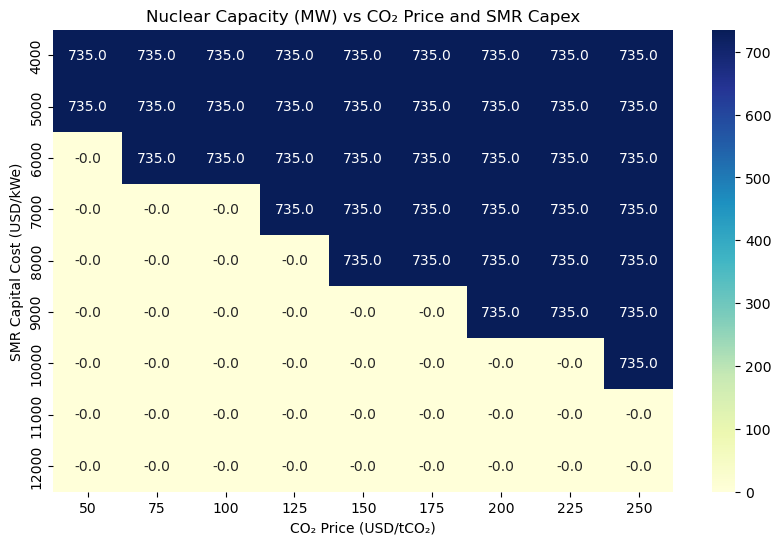

In [11]:
co2_prices = np.arange(50, 251, 25)
capex_range = np.arange(4000, 12001, 1000)
results = pd.DataFrame(index=capex_range, columns=co2_prices)

for capex in capex_range:
    for price in co2_prices:
        cost.loc["SMR_CHP", "investment"] = capex
        cost.loc["Gas_CHP", "carbon_cost"] = price
        # ... (recalcula annualized_investment, reconstruye y resuelve el modelo) ...
    
        select_rate=cost.loc["SMR_CHP","rate"] #Sensibility parameters
        cost["tax"] = cost["tax"].astype(float) # assign as float
        cost.loc["SMR_CHP", "tax"]=16.31 #impact of taxes, 16.31 // Source PWC 

        #annualiaze investment costs
        lifetime= cost["lifetime"].values
        annualized_inv=[packages.annualized(val, select_rate, lifetime[i])*1000 for i, val 
        in enumerate(cost["investment"].values)] #1000_factor_to_convert_to_USD/MW/year
        cost["annualized_investment"]=annualized_inv #Add to cost dataframe

        # Filter a specific time range (test hypotheses)------
        start_time = "2023-01-01 00:00:00" # start of the simulation
        # start_time = "2023-01-02 01:00:00"   # shortTime range quick analysis
        # end_time = "2023-01-02 10:00:00" # shortTime range quick amalysis
        end_time = "2023-12-31 23:00:00"              # All 8760 hours of simulation 
        snapshots=pd.date_range(start_time, end_time, freq="h")
        num_snapshots = len(snapshots) # save hours of simulation in the time range
        #-----------------------------------------------------------------------------
        # Cargar el archivo ES_Price.csv e indexarlo con una serie temporal
        # price_data = pd.read_csv('./ES_Price.csv')
        # price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
        # filtered_prices = price_data.loc[start_time:end_time]
        #-----------------------------------------------------------------------------
        #-----------------------------------------------------------------------------
        heat_demand= 294 # MWth
        electricity_demand=135 # MWe
        Heat_EnergyT=heat_demand*num_snapshots #MWh_th
        PowerT=(heat_demand+electricity_demand)
        EnergyT=PowerT*num_snapshots #MWh in whole simulation
        NGas_max=Heat_EnergyT/0.33 
        #------------------------------------------------------------------------------
        #------------------------------------------------------------------------------
        network=pypsa.Network() # Creates empty PyPSA network object called network
        #Each hour is a snapshot to optimize (Historical ES prices, have 8760 inputs)
        network.set_snapshots(snapshots) # set the time range with hourly frequency

        # 0) define carriers and co2 emissions per unit of carrier consumed [tCO2/MWh_th]
        network.add("Carrier", "Gas",
                    co2_emissions=cost.loc["Gas_CHP","carbon_intensity"]) # tCO2/MWh_th
        network.add("Carrier", "nuclear") # tCO2/MWh_th
        network.add("Carrier", "heat")
        network.add("Carrier","electricity") #output 

        # CO2_reduction=0.5 # 80% CO2 emissions reduction for 2035
        # MaxCO2_possible=cost.loc["Gas_CHP", "carbon_intensity"]*NGas_max # 2.92E+06 fuel avoided in MWh/year (maximum avoided [MECS 2018] considering fuel as 100% natural gas) 
        # limit_CO2=MaxCO2_possible*CO2_reduction # 50% reduction of CO2 emissions in tCO2/year
        # network.add("GlobalConstraint", 
        #             "co2_limit",           #arbitrary name
        #             sense="<=",            # attribute of the constraint
        #             carrier_attribute="co2_emissions",  # Specify what variable is affected
        #             constant=limit_CO2)                 # limit for the simulation

        # 1) Main Buses & loads--------------------------------------------------------
        network.add("Bus", "Industry Electricity", carrier="electricity") 
        network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand) # 135 MWe

        network.add("Bus", "Industry Heat", carrier="heat")
        network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand) # 294 MWth

        # 2)  Fuel buses --------------------------------------------------------------
        network.add("Bus", "uranium_UO2", carrier="nuclear")                  
        network.add("Bus", "Gas_Fuel_in", carrier="Gas")
        network.add("Bus", "Spain_grid", carrier="electricity")

        # STORES ----------------------------------------------------------------------
        network.add("Store", "Spain gas", bus="Gas_Fuel_in",
            e_initial=1e100, 
            # e_nom=0,    # set pre-existing e_nom=50?
            # e_cyclic=True,
            e_nom_extendable=True)
        network.add("Store", "uranium", bus="uranium_UO2",
            e_initial=1e100, 
            # e_nom=0, # set pre-existing e_nom=0?
            # e_cyclic=True,
            e_nom_extendable=True)
        network.add("Store", "Spain grid", bus="Spain_grid",
            e_initial=1e100, 
            # e_nom=100, # set pre-existing e_nom=0?
            # e_cyclic=True,
            e_nom_extendable=True)
        #------------------------------------------------------------------------------
        # DUMP components with one-directional link (+bus+store)-----------------------
        network.add("Bus", "Heat Dump", carrier="heat")
        network.add("Link", "Heat_Dump_Link",
            bus0="Industry Heat",
            bus1="Heat Dump",
            p_nom=1e10,
            # p_nom_extendable=True,
            capital_cost=1, # 400 USD/MW·year
            marginal_cost=0.1, # 40 USD/MWh
            efficiency=1)
        network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
            e_initial=0, 
            e_nom=1e100) # set large e_nom

        network.add("Bus", "Electricity Dump", carrier="electricity") 
        network.add( "Link", "Electricity_Dump_Link",
            bus0="Industry Electricity",
            bus1="Electricity Dump",
            p_nom=1e10,
            # p_nom_extendable=True,
            capital_cost=1, # 400 USD/MW·year
            marginal_cost=-1, # 80 USD/MWh
            efficiency=1)
        network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
            e_initial=0, 
            e_nom=1e100) # set large e_nom
        #------------------------------------------------------------------------------
        # LINKS------------------------------------------------------------------------
        network.add( "Link", "Link_Gas_CHP",               
            bus0="Gas_Fuel_in",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            # carrier="Gas",
            p_nom_min=0,  # Optional: Minimum capacity
            p_nom_max=PowerT*3, # maximum capacity of 1000 MW
            p_nom_extendable=True, # Optimizes de p_nom value
            capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
            marginal_cost=(cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]+cost.loc["Gas_CHP","carbon_cost"]*cost.loc["Gas_CHP","carbon_intensity"]), 
            efficiency=0.35, 
            efficiency2=0.33,
        )
        network.add( "Link", "Link_SMR_CHP",
            bus0="uranium_UO2",
            bus1="Industry Electricity",
            bus2="Industry Heat", 
            # carrier="nuclear",
            p_nom_min=0,  # Optional: Minimum capacity
            p_nom_max= PowerT*3, # maximum capacity of 1000 MW
            p_nom_extendable=True, # Optimizes de p_nom value
            capital_cost=cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"]*1000, #annualized USD/MWe
            marginal_cost=(cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),
            # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], #use LCOE as marginal cost
            efficiency=0.37, 
            efficiency2=0.40,
        )
        network.add("Link", "Link_Spain_Grid",
            bus0="Spain_grid",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            # carrier="electricity",
            p_nom=200, 
            capital_cost=1, # USD/MW·year (no capital cost for grid)
            marginal_cost=80, # Spain energy prices for 2023
            efficiency=1,      # no loss consideration in electricity transport
            efficiency2=0, # no heat generation
            )
        network.optimize()
        #------------------------------------------------------------------------------
        results.at[capex, price] = network.links.at["Link_SMR_CHP", "p_nom_opt"]
        # shadow_price = network.global_constraints.at["co2_limit", "mu"]
        # print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")
        #------------------------------------------------------------------------------
# Visualización heatmap
plt.figure(figsize=(10,6))
sns.heatmap(results.astype(float), annot=True, fmt=".1f", cmap="YlGnBu")
plt.xlabel("CO₂ Price (USD/tCO₂)")
plt.ylabel("SMR Capital Cost (USD/kWe)")
plt.title("Nuclear Capacity (MW) vs CO₂ Price and SMR Capex")
plt.show()

## D) Gas sensitivity 

(15-50 USD/MWh with 80 USD/tCO2)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 13.42it/s]
INFO:linopy.io: Writing time: 3.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals
Objective: 3.49e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00,  9.66it/s]
INFO:linopy.io: Writing time: 2.74s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals


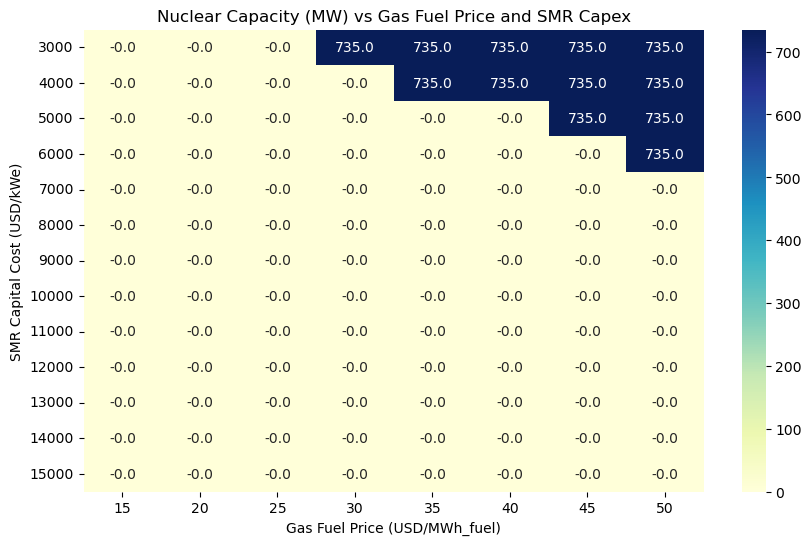

In [8]:
GasFuel_prices = np.arange(15, 51, 5)
capex_range = np.arange(3000, 15001, 1000)
results = pd.DataFrame(index=capex_range, columns=GasFuel_prices)

for capex in capex_range:
    for GasPrice in GasFuel_prices:
        cost.loc["Gas_CHP", "fuel"] = GasPrice # USD/MWh
        cost.loc["SMR_CHP", "investment"] = capex 
        cost.loc["Gas_CHP", "carbon_cost"] = 80 # USD/tCO2
        # ... (recalcula annualized_investment, reconstruye y resuelve el modelo) ...
    
        select_rate=cost.loc["SMR_CHP","rate"] #Sensibility parameters
        cost["tax"] = cost["tax"].astype(float) # assign as float
        cost.loc["SMR_CHP", "tax"]=16.31 #impact of taxes, 16.31 // Source PWC 

        #annualiaze investment costs
        lifetime= cost["lifetime"].values
        annualized_inv=[packages.annualized(val, select_rate, lifetime[i])*1000 for i, val 
        in enumerate(cost["investment"].values)] #1000_factor_to_convert_to_USD/MW/year
        cost["annualized_investment"]=annualized_inv #Add to cost dataframe

        # Filter a specific time range (test hypotheses)------
        start_time = "2023-01-01 00:00:00" # start of the simulation
        # start_time = "2023-01-02 01:00:00"   # shortTime range quick analysis
        # end_time = "2023-01-02 10:00:00" # shortTime range quick amalysis
        end_time = "2023-12-31 23:00:00"              # All 8760 hours of simulation 
        snapshots=pd.date_range(start_time, end_time, freq="h")
        num_snapshots = len(snapshots) # save hours of simulation in the time range
        #-----------------------------------------------------------------------------
        # Cargar el archivo ES_Price.csv e indexarlo con una serie temporal
        # price_data = pd.read_csv('./ES_Price.csv')
        # price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
        # filtered_prices = price_data.loc[start_time:end_time]
        #-----------------------------------------------------------------------------
        #-----------------------------------------------------------------------------
        heat_demand= 294 # MWth
        electricity_demand=135 # MWe
        Heat_EnergyT=heat_demand*num_snapshots #MWh_th
        PowerT=(heat_demand+electricity_demand)
        EnergyT=PowerT*num_snapshots #MWh in whole simulation
        NGas_max=Heat_EnergyT/0.33 
        #------------------------------------------------------------------------------
        #------------------------------------------------------------------------------
        network=pypsa.Network() # Creates empty PyPSA network object called network
        #Each hour is a snapshot to optimize (Historical ES prices, have 8760 inputs)
        network.set_snapshots(snapshots) # set the time range with hourly frequency

        # 0) define carriers and co2 emissions per unit of carrier consumed [tCO2/MWh_th]
        network.add("Carrier", "Gas",
                    co2_emissions=cost.loc["Gas_CHP","carbon_intensity"]) # tCO2/MWh_th
        network.add("Carrier", "nuclear") # tCO2/MWh_th
        network.add("Carrier", "heat")
        network.add("Carrier","electricity") #output 

        # 1) Main Buses & loads--------------------------------------------------------
        network.add("Bus", "Industry Electricity", carrier="electricity") 
        network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand) # 135 MWe

        network.add("Bus", "Industry Heat", carrier="heat")
        network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand) # 294 MWth

        # 2)  Fuel buses --------------------------------------------------------------
        network.add("Bus", "uranium_UO2", carrier="nuclear")                  
        network.add("Bus", "Gas_Fuel_in", carrier="Gas")
        network.add("Bus", "Spain_grid", carrier="electricity")

        # STORES ----------------------------------------------------------------------
        network.add("Store", "Spain gas", bus="Gas_Fuel_in",
            e_initial=1e100, 
            # e_nom=0,    # set pre-existing e_nom=50?
            # e_cyclic=True,
            e_nom_extendable=True)
        network.add("Store", "uranium", bus="uranium_UO2",
            e_initial=1e100, 
            # e_nom=0, # set pre-existing e_nom=0?
            # e_cyclic=True,
            e_nom_extendable=True)
        network.add("Store", "Spain grid", bus="Spain_grid",
            e_initial=1e100, 
            # e_nom=100, # set pre-existing e_nom=0?
            # e_cyclic=True,
            e_nom_extendable=True)
        #------------------------------------------------------------------------------
        # DUMP components with one-directional link (+bus+store)-----------------------
        network.add("Bus", "Heat Dump", carrier="heat")
        network.add("Link", "Heat_Dump_Link",
            bus0="Industry Heat",
            bus1="Heat Dump",
            p_nom=1e10,
            # p_nom_extendable=True,
            capital_cost=1, # 400 USD/MW·year
            marginal_cost=0.1, # 40 USD/MWh
            efficiency=1)
        network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
            e_initial=0, 
            e_nom=1e100) # set large e_nom

        network.add("Bus", "Electricity Dump", carrier="electricity") 
        network.add( "Link", "Electricity_Dump_Link",
            bus0="Industry Electricity",
            bus1="Electricity Dump",
            p_nom=1e10,
            # p_nom_extendable=True,
            capital_cost=1, # 400 USD/MW·year
            marginal_cost=-1, # 80 USD/MWh
            efficiency=1)
        network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
            e_initial=0, 
            e_nom=1e100) # set large e_nom
        #------------------------------------------------------------------------------
        # LINKS------------------------------------------------------------------------
        network.add( "Link", "Link_Gas_CHP",               
            bus0="Gas_Fuel_in",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            # carrier="Gas",
            p_nom_min=0,  # Optional: Minimum capacity
            p_nom_max=PowerT*3, # maximum capacity of 1000 MW
            p_nom_extendable=True, # Optimizes de p_nom value
            capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
            marginal_cost=(cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]+cost.loc["Gas_CHP","carbon_cost"]*cost.loc["Gas_CHP","carbon_intensity"]), 
            efficiency=0.35, 
            efficiency2=0.33,
        )
        network.add( "Link", "Link_SMR_CHP",
            bus0="uranium_UO2",
            bus1="Industry Electricity",
            bus2="Industry Heat", 
            # carrier="nuclear",
            p_nom_min=0,  # Optional: Minimum capacity
            p_nom_max= PowerT*3, # maximum capacity of 1000 MW
            p_nom_extendable=True, # Optimizes de p_nom value
            capital_cost=cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"]*1000, #annualized USD/MWe
            marginal_cost=(cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),
            # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], #use LCOE as marginal cost
            efficiency=0.37, 
            efficiency2=0.40,
        )
        network.add("Link", "Link_Spain_Grid",
            bus0="Spain_grid",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            # carrier="electricity",
            p_nom=200, 
            capital_cost=1, # USD/MW·year (no capital cost for grid)
            marginal_cost=80, # Spain energy prices for 2023
            efficiency=1,      # no loss consideration in electricity transport
            efficiency2=0, # no heat generation
            )
        network.optimize()
        #------------------------------------------------------------------------------
        results.at[capex, GasPrice] = network.links.at["Link_SMR_CHP", "p_nom_opt"]
        # shadow_price = network.global_constraints.at["co2_limit", "mu"]
        # print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")
        #------------------------------------------------------------------------------
# Visualización heatmap
plt.figure(figsize=(10,6))
sns.heatmap(results.astype(float), annot=True, fmt=".1f", cmap="YlGnBu")
plt.xlabel("Gas Fuel Price (USD/MWh_fuel)")
plt.ylabel("SMR Capital Cost (USD/kWe)")
plt.title("Nuclear Capacity (MW) vs Gas Fuel Price and SMR Capex")
plt.show()

# 3 Results
- capital / Marginal Costs per tech
- Mix graph
- CO_2 analysis

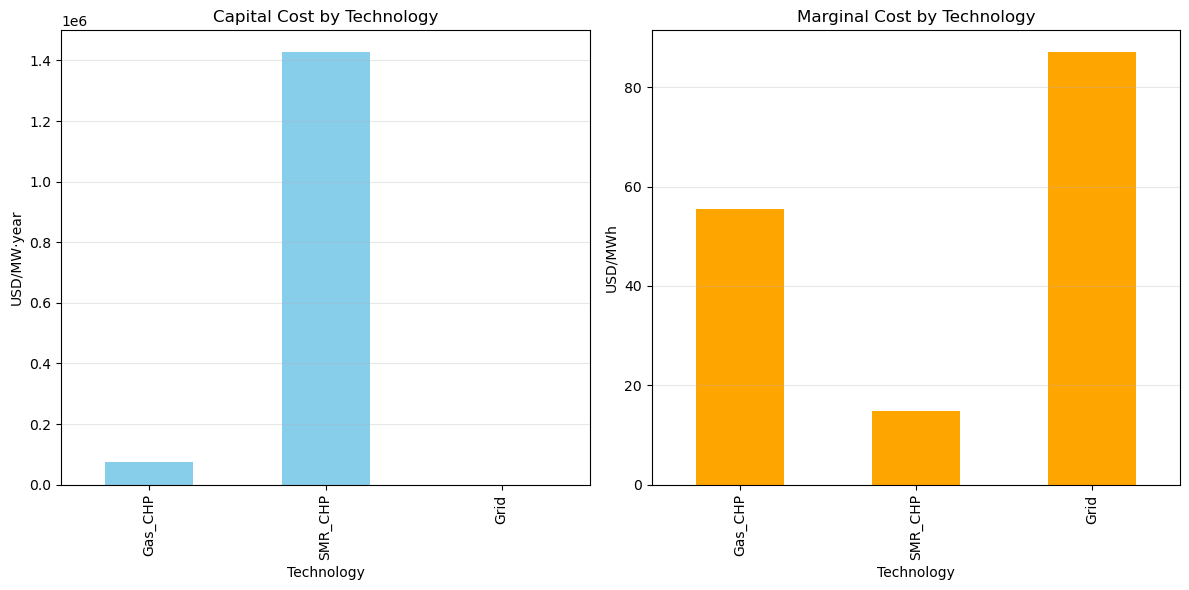

,Technology,Capital Cost (USD/MW·year),Marginal Cost (USD/MWh)
0,Gas_CHP,7.525691e+04,55.500000
1,SMR_CHP,1.427969e+06,14.800000
2,Grid,1.000000e+00,87.105653


In [16]:
# Define the data
data = {
    "Technology": ["Gas_CHP", "SMR_CHP", "Grid"],
    "Capital Cost (USD/MW·year)": [
        cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
        (cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000),
        1  # Grid has no capital cost
    ],
    "Marginal Cost (USD/MWh)": [
        cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"],
        cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"],
        filtered_prices["Price"].mean()  # Average price for the grid
    ]
}
# Create a DataFrame
costs_df = pd.DataFrame(data)

# Plot the data as a bar chart
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Capital Cost Bar Chart
costs_df.plot(
    x="Technology",
    y="Capital Cost (USD/MW·year)",
    kind="bar",
    ax=ax[0],
    color="skyblue",
    legend=False
    )
ax[0].set_title("Capital Cost by Technology")
ax[0].set_ylabel("USD/MW·year")
ax[0].set_xlabel("Technology")
ax[0].grid(axis="y", alpha=0.3)

# Marginal Cost Bar Chart
costs_df.plot(
    x="Technology",
    y="Marginal Cost (USD/MWh)",
    kind="bar",
    ax=ax[1],
    color="orange",
    legend=False
    )
ax[1].set_title("Marginal Cost by Technology")
ax[1].set_ylabel("USD/MWh")
ax[1].set_xlabel("Technology")
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Display the table with a title
display(HTML("<h3>Cost Comparison Table</h3>"))
display(costs_df)

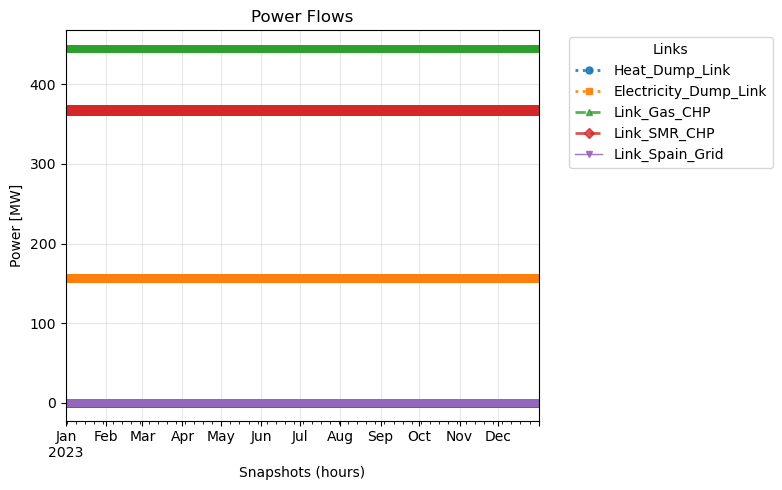

CO2 constraint value: 772632.0
             co2_emissions color nice_name  max_growth  max_relative_growth
Carrier                                                                    
Gas                  0.198                         inf                  0.0
nuclear              0.000                         inf                  0.0
heat                 0.000                         inf                  0.0
electricity          0.000                         inf                  0.0
Total CO₂ emissions in the solution: 772632.00 tCO₂


In [26]:

# Plot all energy flows with different geometric markers for each line
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'x', '+']  # Define a list of markers
ax = network.links_t.p0.plot(
    figsize=(8, 5), 
    title="Power Flows", 
    style='-',  # Use lines by default
    alpha=0.9,  # Set transparency
    linewidth=1  # Adjust line width
)

# Assign a unique marker to each line and adjust marker size
for line, column, marker in zip(ax.lines, network.links_t.p0.columns, markers):
    line.set_marker(marker)
    line.set_markersize(line.get_linewidth() * 5)  # Set marker size proportional to line width

# Customize linestyle for CHP and Dump links
for line, column in zip(ax.lines, network.links_t.p0.columns):
    if "CHP" in column:  # Check if the link name contains "CHP"
        line.set_alpha(0.8)  # Increase transparency
        line.set_linewidth(2)  # Increase line width
        line.set_linestyle("--")  # Set linestyle to dashed
    if "Dump" in column:  # Check if the link name contains "Dump"
        line.set_alpha(0.9)  # Increase transparency
        line.set_linewidth(2)  # Increase line width
        line.set_linestyle(":")  # Set linestyle to dotted

plt.xlabel("Snapshots (hours)")  # Label for x-axis
plt.ylabel("Power [MW]")         # Label for y-axis
plt.legend(title="Links", bbox_to_anchor=(1.05, 1), loc='upper left')  # Add a legend
plt.tight_layout()               # Adjust layout to prevent overlapping
plt.grid(alpha=0.3)              # Add a grid for better readability
plt.show()

# Calculate total CO2 emissions in the solution
if "co2_limit" in network.global_constraints.index:
    print("CO2 constraint value:", network.global_constraints.at["co2_limit", "constant"])
    print(network.carriers)
else:
    print("CO2 constraint not found.")
    
# Calculate total CO₂ emissions from all links with a fuel input and emission factor
total_co2 = 0
for link_name, link in network.links.iterrows():
    carrier = link['carrier']
    if carrier in network.carriers.index and 'co2_emissions' in network.carriers.columns:
        co2_factor = network.carriers.at[carrier, 'co2_emissions']  # tCO2/MWh_th
        # Sum fuel input over all snapshots (p0 is fuel input)
        if link_name in network.links_t.p0.columns:
            fuel_input = network.links_t.p0[link_name].sum()  # MWh_th
            total_co2 += fuel_input * co2_factor
print(f"Total CO₂ emissions in the solution: {total_co2:.2f} tCO₂")

- 3.3 Power [MW] x 10 [h] = amount of energy [MWh]

In [18]:
display(HTML("<h3>Fuel consumption (input) </h3>"))
display(network.links_t.p0) # fuel consumption (input)
display(HTML("<h3>Electricity Output</h3>"))
display(network.links_t.p1) # electricity output (negative values indicates it provides energy out)
display(HTML("<h3>Heat Output</h3>"))
display(network.links_t.p2) # heat output
print(network.objective)  # Verify cost objective value

Link,Heat_Dump_Link,Electricity_Dump_Link,Link_Gas_CHP,Link_SMR_CHP,Link_Spain_Grid
snapshot,,,,,
2023-01-01 00:00:00,-0.0,176.818182,890.909091,-0.0,-0.0
2023-01-01 01:00:00,-0.0,176.818182,890.909091,-0.0,-0.0
2023-01-01 02:00:00,-0.0,176.818182,890.909091,-0.0,-0.0
2023-01-01 03:00:00,-0.0,176.818182,890.909091,-0.0,-0.0
2023-01-01 04:00:00,-0.0,176.818182,890.909091,-0.0,-0.0
...,...,...,...,...,...
2023-12-31 19:00:00,-0.0,176.818182,890.909091,-0.0,-0.0
2023-12-31 20:00:00,-0.0,176.818182,890.909091,-0.0,-0.0
2023-12-31 21:00:00,-0.0,176.818182,890.909091,-0.0,-0.0


Link,Heat_Dump_Link,Electricity_Dump_Link,Link_Gas_CHP,Link_SMR_CHP,Link_Spain_Grid
snapshot,,,,,
2023-01-01 00:00:00,0.0,-176.818182,-311.818182,0.0,0.0
2023-01-01 01:00:00,0.0,-176.818182,-311.818182,0.0,0.0
2023-01-01 02:00:00,0.0,-176.818182,-311.818182,0.0,0.0
2023-01-01 03:00:00,0.0,-176.818182,-311.818182,0.0,0.0
2023-01-01 04:00:00,0.0,-176.818182,-311.818182,0.0,0.0
...,...,...,...,...,...
2023-12-31 19:00:00,0.0,-176.818182,-311.818182,0.0,0.0
2023-12-31 20:00:00,0.0,-176.818182,-311.818182,0.0,0.0
2023-12-31 21:00:00,0.0,-176.818182,-311.818182,0.0,0.0


Link,Heat_Dump_Link,Electricity_Dump_Link,Link_Gas_CHP,Link_SMR_CHP,Link_Spain_Grid
snapshot,,,,,
2023-01-01 00:00:00,0.0,0.0,-294.0,0.0,0.0
2023-01-01 01:00:00,0.0,0.0,-294.0,0.0,0.0
2023-01-01 02:00:00,0.0,0.0,-294.0,0.0,0.0
2023-01-01 03:00:00,0.0,0.0,-294.0,0.0,0.0
2023-01-01 04:00:00,0.0,0.0,-294.0,0.0,0.0
...,...,...,...,...,...
2023-12-31 19:00:00,0.0,0.0,-294.0,0.0,0.0
2023-12-31 20:00:00,0.0,0.0,-294.0,0.0,0.0
2023-12-31 21:00:00,0.0,0.0,-294.0,0.0,0.0


884956316.6365044


In [19]:
print("SMR Electricity Output:", network.links_t.p1["Link_SMR_CHP"].sum() )  # -MW
print("SMR Heat Output:", network.links_t.p2["Link_SMR_CHP"].sum())         # -MW
print("SMR Uranium Fuel Consumption:", network.links_t.p0["Link_SMR_CHP"].sum())    #+ MW

print("Gas_CHP Electricity Output:", network.links_t.p1["Link_Gas_CHP"].sum())
print("Gas_CHP Gas Consumption:", network.links_t.p0["Link_Gas_CHP"].sum())

print("Grid electricity output:", network.links_t.p1["Link_Spain_Grid"].sum())
print("Grid electricity Consumption:", network.links_t.p0["Link_Spain_Grid"].sum())

SMR Electricity Output: 0.0
SMR Heat Output: 0.0
SMR Uranium Fuel Consumption: 0.0
Gas_CHP Electricity Output: -2731527.2727272734
Gas_CHP Gas Consumption: 7804363.636363633
Grid electricity output: 0.0
Grid electricity Consumption: 0.0


Note that negative values for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive). 

- network.links_t.p0 # energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE
- network.links_t.p1 # energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)
- network.links_t.p2 # energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)

In [20]:
from IPython.display import display, HTML

# Define the data
data = {
    "Technology": ["Gas_CHP", "SMR_CHP", "Grid"],
    "Capital Cost (USD/MW·year)": [
        cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
        cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000,
        0  # Grid has no capital cost
    ],
    "Marginal Cost (USD/MWh)": [
        cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"]+cost.loc["Gas_CHP","carbon_cost"]*cost.loc["Gas_CHP","carbon_intensity"],
        cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"],
        filtered_prices["Price"].mean()  # Average price for the grid
    ]
}
costs_df = pd.DataFrame(data) # Create a DataFrame
display(HTML("<h3>Cost Comparison Table</h3>")) # Display the table with a title
display(costs_df)

,Technology,Capital Cost (USD/MW·year),Marginal Cost (USD/MWh)
0,Gas_CHP,7.525691e+04,105.000000
1,SMR_CHP,1.427969e+06,14.800000
2,Grid,0.000000e+00,87.105653
